# 03B: LSTM Forecasting Model

**Project:** Multi-Disease Outbreak Forecasting with Temporal Deep Learning  
**Research Question:** Can we accurately forecast short-term disease incidence (4–8 weeks ahead) across Canadian provinces using historical weekly case counts, and does a deep learning approach (LSTM) outperform classical baselines such as ARIMA or Prophet?  
**End User:** Provincial and federal public health agencies (e.g., PHAC), epidemiologists, health system planners.

This notebook trains an optimised stacked LSTM model for multi-step disease incidence forecasting. It loads the feature-engineered windows from notebook `01`, applies a log1p target transformation to address heavy right-skew in the training data, runs a structured hyperparameter grid search, then fully trains the winning configuration and evaluates it on the validation set.

**Inputs (from `01`):**
- `data/processed/windows/features/X_{train,val,test}_feat.npy` — shape `(n_windows, 52, 6)`
- `data/processed/windows/features/y_{train,val,test}_feat.npy` — shape `(n_windows, 8)`
- `data/processed/windows/features/feature_window_config.json`

**Outputs:**
- `models/lstm_baseline/lstm_baseline_best.pt` — best model weights (lowest val Huber loss)
- `models/lstm_baseline/lstm_baseline_config.json` — architecture + training config
- `models/lstm_baseline/training_history.csv` — per-epoch loss log
- `reports/tables/hp_search_results.csv` — full grid search results table
- `reports/tables/val_metrics.csv` — per-horizon RMSE/MAE in original scale
- `reports/figures/fig3_0_hp_search.png` — grid search visualisation
- `reports/figures/fig3_1_lstm_training_curves.png` — training/validation loss curves
- `reports/figures/fig3_1b_lstm_per_horizon_errors.png` — per-horizon error bars
- `reports/figures/fig3_2_lstm_forecast_samples.png` — sample forecast overlays

---
## 1 · Setup

In [37]:
import os

# Suppress duplicate OpenMP runtime warning on macOS
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

REPO_DIR = "/Users/deansimmer/git/AAI-590-capstone-canadian-health"

In [38]:
# ── Ensure output directories exist ───────────────────────────────────────────
MODEL_DIR   = os.path.join(REPO_DIR, "models", "lstm_baseline")
FIGURES_DIR = os.path.join(REPO_DIR, "reports", "figures")
FEAT_DIR    = os.path.join(REPO_DIR, "data", "processed", "windows", "features")

for d in [MODEL_DIR, FIGURES_DIR, FEAT_DIR]:
    os.makedirs(d, exist_ok=True)
    print(f"  {d}")

  /Users/deansimmer/git/AAI-590-capstone-canadian-health/models/lstm_baseline
  /Users/deansimmer/git/AAI-590-capstone-canadian-health/reports/figures
  /Users/deansimmer/git/AAI-590-capstone-canadian-health/data/processed/windows/features


---
## 2 · Imports & Reproducibility

In [39]:
import json
import time
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# ── Reproducibility seed ───────────────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# ── Device ────────────────────────────────────────────────────────────────────
DEVICE = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)
print(f"PyTorch version : {torch.__version__}")
print(f"Device          : {DEVICE}")
if DEVICE.type == "cuda":
    print(f"GPU             : {torch.cuda.get_device_name(0)}")
elif DEVICE.type == "mps":
    print(f"GPU             : Apple Metal (MPS)")

PyTorch version : 2.11.0
Device          : mps
GPU             : Apple Metal (MPS)


---
## 3 · Hyperparameters & Configuration

All tunable values are collected here as the single source of truth for a training run. Downstream cells read from this block rather than using hard-coded literals.

**Key changes from baseline:**
- **`USE_LOG1P = True`** — applies `log1p` to all targets before training and `expm1` after prediction. The training targets are heavily right-skewed (max 118 cases/100k, std 4.35), and log-compressing them dramatically narrows the effective loss range, stabilises gradients, and reduces the train/val gap caused by historical outbreak spikes.
- **`HuberLoss(delta=1.0)`** — replaces MSE. Huber acts like MSE for small errors and like MAE for large ones, making the loss surface more robust to the residual outliers that survive log-compression.
- **Deeper projection head** (`FC_HIDDEN = 64`) — adds a `Linear→GELU→Dropout→Linear` block between the LSTM encoder and the 8-step output, giving the model more representational capacity to decode multi-step forecasts from the single final hidden state.
- **Increased patience** — `LR_PATIENCE 5 → 10`, `EARLY_STOP_PAT 15 → 25`, `MAX_EPOCHS 150 → 200`. The previous run stopped at epoch 23 with best weights at epoch 8; the model barely converged before training was terminated.

In [40]:
# ── Data dimensions (must match feature_window_config.json from notebook 01) ──
LOOKBACK_WEEKS   = 52   # number of input timesteps per window
FORECAST_HORIZON = 8    # number of weeks ahead to forecast
N_FEATURES       = 6    # features per timestep

FEATURE_NAMES = [
    "cases_per_100k",     # population-normalised weekly incidence (prediction target)
    "roll4_per_100k",     # 4-week rolling mean
    "roll13_per_100k",    # 13-week (quarterly) rolling mean
    "roll52_per_100k",    # 52-week (annual) rolling mean
    "week_sin",           # cyclical week-of-year encoding (sine)
    "week_cos",           # cyclical week-of-year encoding (cosine)
]
TARGET_FEATURE_IDX = 0  # cases_per_100k is the first feature and the forecast target

# ── Target transformation ──────────────────────────────────────────────────
# Training targets span 0–118 cases/100k with heavy right skew (std=4.35).
# log1p compresses the scale to 0–4.78 and makes gradient magnitudes tractable.
USE_LOG1P = True         # apply log1p to y before training; expm1 after prediction

# ── LSTM architecture ─────────────────────────────────────────────────────────
HIDDEN_SIZE  = 128   # number of units in each LSTM layer
NUM_LAYERS   = 2     # number of stacked LSTM layers
DROPOUT      = 0.2   # dropout applied between LSTM layers and before the output head
FC_HIDDEN    = 64    # hidden units in the two-layer projection head (0 = single linear)

# ── Training ──────────────────────────────────────────────────────────────────
BATCH_SIZE      = 256
MAX_EPOCHS      = 200    # increased from 150 — early stopping provides the real ceiling
LEARNING_RATE   = 1e-3
WEIGHT_DECAY    = 1e-5   # L2 regularisation on Adam
LR_PATIENCE     = 10     # increased from 5 — gives the model more room before LR drops
LR_FACTOR       = 0.5
LR_MIN          = 1e-6
EARLY_STOP_PAT  = 25     # increased from 15 — was stopping the run at epoch 23

# ── Loss ──────────────────────────────────────────────────────────────────────
# HuberLoss(delta=1.0): behaves like MSE for |error| < 1.0, like MAE for larger errors.
# More robust to the outlier outbreak weeks that survive log-compression.
HUBER_DELTA = 1.0

# ── Snapshot for saving ───────────────────────────────────────────────────────
RUN_CONFIG = {
    "seed":             SEED,
    "lookback_weeks":   LOOKBACK_WEEKS,
    "forecast_horizon": FORECAST_HORIZON,
    "n_features":       N_FEATURES,
    "feature_names":    FEATURE_NAMES,
    "target_feature":   "cases_per_100k",
    "use_log1p":        USE_LOG1P,
    "hidden_size":      HIDDEN_SIZE,
    "num_layers":       NUM_LAYERS,
    "dropout":          DROPOUT,
    "fc_hidden":        FC_HIDDEN,
    "batch_size":       BATCH_SIZE,
    "max_epochs":       MAX_EPOCHS,
    "learning_rate":    LEARNING_RATE,
    "weight_decay":     WEIGHT_DECAY,
    "lr_patience":      LR_PATIENCE,
    "lr_factor":        LR_FACTOR,
    "lr_min":           LR_MIN,
    "early_stop_patience": EARLY_STOP_PAT,
    "loss_fn":          f"HuberLoss(delta={HUBER_DELTA})",
    "optimizer":        "Adam",
}

print("Run configuration:")
for k, v in RUN_CONFIG.items():
    print(f"  {k:<25} {v}")

Run configuration:
  seed                      42
  lookback_weeks            52
  forecast_horizon          8
  n_features                6
  feature_names             ['cases_per_100k', 'roll4_per_100k', 'roll13_per_100k', 'roll52_per_100k', 'week_sin', 'week_cos']
  target_feature            cases_per_100k
  use_log1p                 True
  hidden_size               128
  num_layers                2
  dropout                   0.2
  fc_hidden                 64
  batch_size                256
  max_epochs                200
  learning_rate             0.001
  weight_decay              1e-05
  lr_patience               10
  lr_factor                 0.5
  lr_min                    1e-06
  early_stop_patience       25
  loss_fn                   HuberLoss(delta=1.0)
  optimizer                 Adam


---
## 4 · Load Preprocessed Windows

The `.npy` arrays were created in notebook `01` (Section 18.5). They contain sliding windows over every province × disease time series that survived quality filtering. Each window provides 52 weeks of 6-feature input and an 8-week forecast target, both expressed in `cases_per_100k`.

In [41]:
# ── Load feature window config produced by notebook 01 ────────────────────────
config_path = os.path.join(FEAT_DIR, "feature_window_config.json")
with open(config_path) as f:
    feat_config = json.load(f)

print("Feature window config from notebook 01:")
for k, v in feat_config.items():
    print(f"  {k:<25} {v}")

# Sanity-check that dimensions match our run config
assert feat_config["lookback_weeks"]   == LOOKBACK_WEEKS,   "lookback mismatch"
assert feat_config["forecast_horizon"] == FORECAST_HORIZON, "horizon mismatch"
assert feat_config["n_features"]       == N_FEATURES,       "n_features mismatch"
print("\nDimension assertions passed.")

Feature window config from notebook 01:
  lookback_weeks            52
  forecast_horizon          8
  step_size                 1
  n_features                6
  feature_names             ['cases_per_100k', 'roll4_per_100k', 'roll13_per_100k', 'roll52_per_100k', 'week_sin', 'week_cos']
  target_feature            cases_per_100k
  train_cutoff              1986-01-01
  val_cutoff                2004-01-01
  focus_diseases            ['influenza', 'whooping-cough', 'measles']
  total_windows             20220
  note                      X shape: (n_windows, lookback_weeks, n_features). y is cases_per_100k only — denormalize using provincial population from window_metadata to recover raw case counts at evaluation time.

Dimension assertions passed.


In [42]:
# ── Load numpy arrays ─────────────────────────────────────────────────────────
X_train = np.load(os.path.join(FEAT_DIR, "X_train_feat.npy")).astype(np.float32)
y_train = np.load(os.path.join(FEAT_DIR, "y_train_feat.npy")).astype(np.float32)

X_val   = np.load(os.path.join(FEAT_DIR, "X_val_feat.npy")).astype(np.float32)
y_val   = np.load(os.path.join(FEAT_DIR, "y_val_feat.npy")).astype(np.float32)

X_test  = np.load(os.path.join(FEAT_DIR, "X_test_feat.npy")).astype(np.float32)
y_test  = np.load(os.path.join(FEAT_DIR, "y_test_feat.npy")).astype(np.float32)

print("Array shapes:")
print(f"  X_train : {X_train.shape}   →  (n_windows, lookback_weeks, n_features)")
print(f"  y_train : {y_train.shape}")
print(f"  X_val   : {X_val.shape}")
print(f"  y_val   : {y_val.shape}")
print(f"  X_test  : {X_test.shape}")
print(f"  y_test  : {y_test.shape}")

print("\nTarget (y) statistics — cases_per_100k (RAW, before any transform):")
for name, arr in [("train", y_train), ("val", y_val), ("test", y_test)]:
    print(f"  {name:<6}  mean={arr.mean():.4f}  std={arr.std():.4f}  "
          f"min={arr.min():.4f}  max={arr.max():.4f}")

# ── Apply log1p transform to targets if configured ────────────────────────────
# X arrays are NOT transformed — the LSTM encoder sees the original feature scales.
# Only the y targets (cases_per_100k forecasts) are compressed.
# We keep the raw arrays (y_*_raw) for denormalisation at evaluation time.
y_train_raw = y_train.copy()
y_val_raw   = y_val.copy()
y_test_raw  = y_test.copy()

if USE_LOG1P:
    y_train = np.log1p(y_train)
    y_val   = np.log1p(y_val)
    y_test  = np.log1p(y_test)
    print("\nlog1p applied to targets.")
    print("Target (y) statistics — log1p(cases_per_100k):")
    for name, arr in [("train", y_train), ("val", y_val), ("test", y_test)]:
        print(f"  {name:<6}  mean={arr.mean():.4f}  std={arr.std():.4f}  "
              f"min={arr.min():.4f}  max={arr.max():.4f}")

Array shapes:
  X_train : (12740, 52, 6)   →  (n_windows, lookback_weeks, n_features)
  y_train : (12740, 8)
  X_val   : (3756, 52, 6)
  y_val   : (3756, 8)
  X_test  : (3724, 52, 6)
  y_test  : (3724, 8)

Target (y) statistics — cases_per_100k (RAW, before any transform):
  train   mean=1.7758  std=4.3533  min=0.0000  max=118.1915
  val     mean=0.2329  std=0.9285  min=0.0000  max=24.3788
  test    mean=0.3426  std=1.2163  min=0.0000  max=17.0642

log1p applied to targets.
Target (y) statistics — log1p(cases_per_100k):
  train   mean=0.6224  std=0.7339  min=0.0000  max=4.7807
  val     mean=0.1388  std=0.2906  min=0.0000  max=3.2339
  test    mean=0.1679  std=0.3856  min=0.0000  max=2.8939


In [43]:
# ── Convert to PyTorch tensors and wrap in DataLoaders ────────────────────────
def make_loader(X: np.ndarray, y: np.ndarray,
                batch_size: int, shuffle: bool) -> DataLoader:
    """Wrap numpy arrays in a TensorDataset and return a DataLoader."""
    dataset = TensorDataset(
        torch.from_numpy(X),
        torch.from_numpy(y),
    )
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle,
                      num_workers=2, pin_memory=(DEVICE.type == "cuda"))

train_loader = make_loader(X_train, y_train, BATCH_SIZE, shuffle=True)
val_loader   = make_loader(X_val,   y_val,   BATCH_SIZE, shuffle=False)
test_loader  = make_loader(X_test,  y_test,  BATCH_SIZE, shuffle=False)

print(f"Train batches : {len(train_loader)}")
print(f"Val batches   : {len(val_loader)}")
print(f"Test batches  : {len(test_loader)}")

Train batches : 50
Val batches   : 15
Test batches  : 15


---
## 5 · LSTM Model Architecture

The model is a two-layer stacked LSTM with a **two-layer projection head**. It receives a 52-timestep × 6-feature input and produces an 8-step forecast in a single forward pass (direct multi-step output).

Key design choices:
- **Stacked LSTM (2 layers, hidden=128):** A second recurrent layer captures higher-order temporal dependencies on top of the short-range patterns learned by the first layer.
- **Dropout (0.2) between layers and before the head:** Applied between LSTM layers via PyTorch's built-in `dropout` parameter, and again before the projection head for an extra regularisation nudge.
- **Two-layer projection head (`Linear(128→64)→GELU→Dropout→Linear(64→8)`):** A shallow MLP decoder gives the model more expressive power when mapping the 128-dimensional hidden state to 8 distinct forecast steps, rather than relying on a single linear transformation. GELU is preferred over ReLU for smoother gradient flow in the output path.
- **Huber loss on `log1p(cases_per_100k)`:** Targets are log-compressed before training; the Huber loss then provides robustness to the residual large errors from peak outbreak weeks.

In [44]:
class LSTMForecaster(nn.Module):
    """
    Stacked LSTM for multi-step disease incidence forecasting.

    Input  : (batch, seq_len, n_features)  — e.g. (256, 52, 6)
    Output : (batch, forecast_horizon)     — e.g. (256, 8)

    The encoder is a stacked LSTM that reads the full lookback window.
    The decoder is a two-layer MLP projection head (if fc_hidden > 0)
    or a single linear layer (if fc_hidden == 0).
    """

    def __init__(
        self,
        n_features:       int,
        hidden_size:      int,
        num_layers:       int,
        forecast_horizon: int,
        dropout:          float = 0.0,
        fc_hidden:        int   = 0,
    ):
        super().__init__()

        lstm_dropout = dropout if num_layers > 1 else 0.0

        self.lstm = nn.LSTM(
            input_size=n_features,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=lstm_dropout,
        )

        self.output_dropout = nn.Dropout(dropout)

        # ── Projection head ───────────────────────────────────────────────────
        # fc_hidden > 0 → two-layer MLP: hidden_size → fc_hidden → forecast_horizon
        # fc_hidden == 0 → single linear:              hidden_size → forecast_horizon
        if fc_hidden > 0:
            self.head = nn.Sequential(
                nn.Linear(hidden_size, fc_hidden),
                nn.GELU(),
                nn.Dropout(dropout),
                nn.Linear(fc_hidden, forecast_horizon),
            )
        else:
            self.head = nn.Linear(hidden_size, forecast_horizon)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Parameters
        ----------
        x : (batch, seq_len, n_features)

        Returns
        -------
        out : (batch, forecast_horizon)
        """
        # h_n[-1] : (batch, hidden_size) — top LSTM layer, final timestep
        _, (h_n, _) = self.lstm(x)
        last_hidden  = self.output_dropout(h_n[-1])
        return self.head(last_hidden)       # (batch, forecast_horizon)

In [45]:
# ── Instantiate model and move to device ──────────────────────────────────────
model = LSTMForecaster(
    n_features=N_FEATURES,
    hidden_size=HIDDEN_SIZE,
    num_layers=NUM_LAYERS,
    forecast_horizon=FORECAST_HORIZON,
    dropout=DROPOUT,
    fc_hidden=FC_HIDDEN,
).to(DEVICE)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(model)
print(f"\nTotal parameters     : {total_params:,}")
print(f"Trainable parameters : {trainable_params:,}")

dummy_input = torch.zeros(4, LOOKBACK_WEEKS, N_FEATURES, device=DEVICE)
dummy_out   = model(dummy_input)
assert dummy_out.shape == (4, FORECAST_HORIZON), f"Unexpected output shape: {dummy_out.shape}"
print(f"\nForward-pass check passed. Output shape: {dummy_out.shape}")

LSTMForecaster(
  (lstm): LSTM(6, 128, num_layers=2, batch_first=True, dropout=0.2)
  (output_dropout): Dropout(p=0.2, inplace=False)
  (head): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): GELU(approximate='none')
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=64, out_features=8, bias=True)
  )
)

Total parameters     : 210,504
Trainable parameters : 210,504

Forward-pass check passed. Output shape: torch.Size([4, 8])


---
## 6 · Training Utilities

Core training helpers used both by the single baseline run (Section 7) and the hyperparameter search (Section 8). The `run_epoch` function handles both train and eval passes; `full_training_run` encapsulates the complete training loop, returning the history DataFrame and the path to the best checkpoint.

In [46]:
# ── Loss, optimiser, scheduler for the baseline run ──────────────────────────
criterion = nn.HuberLoss(delta=HUBER_DELTA)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=LR_FACTOR,
    patience=LR_PATIENCE,
    min_lr=LR_MIN,
)

print("Loss fn    :", criterion.__class__.__name__, f"(delta={HUBER_DELTA})")
print("Optimiser  :", optimizer.__class__.__name__)
print("Scheduler  :", scheduler.__class__.__name__, f"(patience={LR_PATIENCE})")

Loss fn    : HuberLoss (delta=1.0)
Optimiser  : Adam
Scheduler  : ReduceLROnPlateau (patience=10)


In [47]:
def run_epoch(loader: DataLoader, train: bool) -> float:
    """
    Run one pass over a DataLoader.

    Parameters
    ----------
    loader : DataLoader — batches of (X, y)
    train  : bool       — if True, compute gradients and update weights

    Returns
    -------
    mean MSE loss over all batches in the loader
    """
    model.train(train)
    total_loss = 0.0

    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(DEVICE, non_blocking=True)
            y_batch = y_batch.to(DEVICE, non_blocking=True)

            preds = model(X_batch)                  # (batch, horizon)
            loss  = criterion(preds, y_batch)

            if train:
                optimizer.zero_grad()
                loss.backward()
                # Gradient clipping prevents exploding gradients in deep RNNs
                nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()

            total_loss += loss.item() * len(X_batch)

    return total_loss / len(loader.dataset)

In [48]:
def full_training_run(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    scheduler,
    max_epochs:        int,
    early_stop_pat:    int,
    checkpoint_path:   str,
    verbose:           bool = True,
) -> tuple[pd.DataFrame, float, int]:
    """
    Full training loop with checkpointing and early stopping.

    Parameters
    ----------
    model, train_loader, val_loader, criterion, optimizer, scheduler
    max_epochs      : upper bound on training epochs
    early_stop_pat  : number of non-improving val epochs before stopping
    checkpoint_path : where to save best model weights (.pt)
    verbose         : if True, print a progress table every 5 epochs

    Returns
    -------
    hist_df       : DataFrame with columns [epoch, train_loss, val_loss, lr]
    best_val_loss : lowest validation loss achieved
    best_epoch    : epoch at which best_val_loss was recorded
    """
    best_val_loss     = float("inf")
    best_epoch        = 0
    epochs_no_improve = 0
    history           = []

    if verbose:
        print(f"{'Epoch':>6}  {'Train Huber':>12}  {'Val Huber':>10}  {'LR':>10}")
        print("-" * 50)

    t0 = time.time()
    for epoch in range(1, max_epochs + 1):
        train_loss = run_epoch(train_loader, train=True)
        val_loss   = run_epoch(val_loader,   train=False)

        scheduler.step(val_loss)
        current_lr = optimizer.param_groups[0]["lr"]
        history.append({"epoch": epoch, "train_loss": train_loss,
                        "val_loss": val_loss, "lr": current_lr})

        if val_loss < best_val_loss:
            best_val_loss     = val_loss
            best_epoch        = epoch
            epochs_no_improve = 0
            torch.save(model.state_dict(), checkpoint_path)
            marker = "  ✓"
        else:
            epochs_no_improve += 1
            marker = ""

        if verbose and (epoch % 5 == 0 or epoch == 1):
            print(f"{epoch:>6}  {train_loss:>12.6f}  {val_loss:>10.6f}  "
                  f"{current_lr:>10.2e}{marker}")

        if epochs_no_improve >= early_stop_pat:
            if verbose:
                print(f"\nEarly stopping at epoch {epoch} "
                      f"({early_stop_pat} epochs without improvement).")
            break

    elapsed = time.time() - t0
    if verbose:
        print(f"\nDone in {elapsed/60:.1f} min  |  "
              f"Best epoch {best_epoch}  |  Best val Huber {best_val_loss:.6f}")

    return pd.DataFrame(history), best_val_loss, best_epoch

In [49]:
# ── Baseline training run ─────────────────────────────────────────────────────
best_model_path = os.path.join(MODEL_DIR, "lstm_baseline_best.pt")

hist_df, best_val_loss, best_epoch = full_training_run(
    model          = model,
    train_loader   = train_loader,
    val_loader     = val_loader,
    criterion      = criterion,
    optimizer      = optimizer,
    scheduler      = scheduler,
    max_epochs     = MAX_EPOCHS,
    early_stop_pat = EARLY_STOP_PAT,
    checkpoint_path= best_model_path,
    verbose        = True,
)

 Epoch   Train Huber   Val Huber          LR
--------------------------------------------------
     1      0.142896    0.022299    1.00e-03  ✓
     5      0.068467    0.019504    1.00e-03  ✓
    10      0.060948    0.019017    1.00e-03  ✓
    15      0.056929    0.023602    1.00e-03
    20      0.053679    0.028528    1.00e-03
    25      0.048698    0.036965    5.00e-04
    30      0.046257    0.030648    5.00e-04
    35      0.043210    0.037025    2.50e-04

Early stopping at epoch 35 (25 epochs without improvement).

Done in 1.2 min  |  Best epoch 10  |  Best val Huber 0.019017


---
## 7 · Hyperparameter Search

A structured grid search over the four most impactful architectural and training parameters. Each trial uses a shortened training budget (`SEARCH_EPOCHS = 40`) with an aggressive early stop (`SEARCH_ES = 8`) to efficiently rank configurations. The winner is identified by lowest validation Huber loss, then fully re-trained in Section 8 with the standard budget.

**Search space:**

| Parameter | Values |
|-----------|--------|
| `hidden_size` | 64, 128, 256 |
| `num_layers` | 1, 2 |
| `dropout` | 0.1, 0.3 |
| `learning_rate` | 3e-4, 1e-3 |

That yields 24 candidate configurations (3 × 2 × 2 × 2). All other hyperparameters (`fc_hidden`, `batch_size`, `weight_decay`, Huber delta, `USE_LOG1P`) are held at the values defined in Section 3.

In [50]:
import itertools

# ── Search budget (short runs for ranking, not for final weights) ──────────
SEARCH_EPOCHS = 40
SEARCH_ES     = 8    # early stop patience for search trials

# ── Grid definition ─────────────────────────────────────────────────────────
SEARCH_GRID = {
    "hidden_size":   [64, 128, 256],
    "num_layers":    [1, 2],
    "dropout":       [0.1, 0.3],
    "learning_rate": [3e-4, 1e-3],
}

keys   = list(SEARCH_GRID.keys())
combos = list(itertools.product(*SEARCH_GRID.values()))
print(f"Total configurations: {len(combos)}")
print(f"Search budget per trial: {SEARCH_EPOCHS} epochs (early stop @ {SEARCH_ES})")
print(f"\n{'#':>3}  {'hidden':>7}  {'layers':>6}  {'dropout':>7}  {'lr':>8}  {'params':>8}")
print("-" * 52)
for i, combo in enumerate(combos):
    cfg = dict(zip(keys, combo))
    # Quick param count estimate for LSTM + head
    h, l = cfg["hidden_size"], cfg["num_layers"]
    lstm_p = 4 * h * (N_FEATURES + h + 1) + (l - 1) * 4 * h * (h + h + 1)
    head_p = h * FC_HIDDEN + FC_HIDDEN + FC_HIDDEN * FORECAST_HORIZON + FORECAST_HORIZON
    total  = lstm_p + head_p
    print(f"{i+1:>3}  {h:>7}  {l:>6}  {cfg['dropout']:>7.1f}  "
          f"{cfg['learning_rate']:>8.0e}  {total:>8,}")

Total configurations: 24
Search budget per trial: 40 epochs (early stop @ 8)

  #   hidden  layers  dropout        lr    params
----------------------------------------------------
  1       64       1      0.1     3e-04    22,856
  2       64       1      0.1     1e-03    22,856
  3       64       1      0.3     3e-04    22,856
  4       64       1      0.3     1e-03    22,856
  5       64       2      0.1     3e-04    55,880
  6       64       2      0.1     1e-03    55,880
  7       64       2      0.3     3e-04    55,880
  8       64       2      0.3     1e-03    55,880
  9      128       1      0.1     3e-04    77,896
 10      128       1      0.1     1e-03    77,896
 11      128       1      0.3     3e-04    77,896
 12      128       1      0.3     1e-03    77,896
 13      128       2      0.1     3e-04   209,480
 14      128       2      0.1     1e-03   209,480
 15      128       2      0.3     3e-04   209,480
 16      128       2      0.3     1e-03   209,480
 17      256       

In [51]:
# ── Run the grid search ───────────────────────────────────────────────────────
# Each trial builds a fresh model and trains for SEARCH_EPOCHS epochs.
# Weights are discarded after scoring; only the results table is kept.

search_results = []
SEARCH_CKPT = os.path.join(MODEL_DIR, "_search_tmp.pt")

for i, combo in enumerate(combos):
    cfg = dict(zip(keys, combo))

    # Build a fresh model for this configuration
    trial_model = LSTMForecaster(
        n_features=N_FEATURES,
        hidden_size=cfg["hidden_size"],
        num_layers=cfg["num_layers"],
        forecast_horizon=FORECAST_HORIZON,
        dropout=cfg["dropout"],
        fc_hidden=FC_HIDDEN,
    ).to(DEVICE)

    trial_optim = torch.optim.Adam(
        trial_model.parameters(),
        lr=cfg["learning_rate"],
        weight_decay=WEIGHT_DECAY,
    )
    trial_sched = torch.optim.lr_scheduler.ReduceLROnPlateau(
        trial_optim, mode="min", factor=LR_FACTOR,
        patience=max(3, LR_PATIENCE // 2), min_lr=LR_MIN,
    )
    trial_crit = nn.HuberLoss(delta=HUBER_DELTA)

    # Temporarily override the global model/optimizer/criterion
    # so run_epoch (which references them) uses this trial's objects
    _orig_model, _orig_opt, _orig_crit = model, optimizer, criterion
    model, optimizer, criterion = trial_model, trial_optim, trial_crit  # noqa

    _, best_loss, best_ep = full_training_run(
        model=trial_model, train_loader=train_loader, val_loader=val_loader,
        criterion=trial_crit, optimizer=trial_optim, scheduler=trial_sched,
        max_epochs=SEARCH_EPOCHS, early_stop_pat=SEARCH_ES,
        checkpoint_path=SEARCH_CKPT, verbose=False,
    )

    # Restore globals
    model, optimizer, criterion = _orig_model, _orig_opt, _orig_crit  # noqa

    row = {**cfg, "val_huber": best_loss, "best_epoch": best_ep}
    search_results.append(row)

    h = cfg["hidden_size"]; l = cfg["num_layers"]
    d = cfg["dropout"];      lr = cfg["learning_rate"]
    print(f"[{i+1:>2}/{len(combos)}]  "
          f"hidden={h:<4}  layers={l}  drop={d:.1f}  lr={lr:.0e}  "
          f"→  val_huber={best_loss:.5f}  (ep {best_ep})")

# Clean up temp checkpoint
if os.path.exists(SEARCH_CKPT):
    os.remove(SEARCH_CKPT)

[ 1/24]  hidden=64    layers=1  drop=0.1  lr=3e-04  →  val_huber=0.02045  (ep 18)
[ 2/24]  hidden=64    layers=1  drop=0.1  lr=1e-03  →  val_huber=0.01911  (ep 13)
[ 3/24]  hidden=64    layers=1  drop=0.3  lr=3e-04  →  val_huber=0.01975  (ep 22)
[ 4/24]  hidden=64    layers=1  drop=0.3  lr=1e-03  →  val_huber=0.01890  (ep 10)
[ 5/24]  hidden=64    layers=2  drop=0.1  lr=3e-04  →  val_huber=0.02011  (ep 7)
[ 6/24]  hidden=64    layers=2  drop=0.1  lr=1e-03  →  val_huber=0.01923  (ep 5)
[ 7/24]  hidden=64    layers=2  drop=0.3  lr=3e-04  →  val_huber=0.02035  (ep 17)
[ 8/24]  hidden=64    layers=2  drop=0.3  lr=1e-03  →  val_huber=0.02025  (ep 5)
[ 9/24]  hidden=128   layers=1  drop=0.1  lr=3e-04  →  val_huber=0.02015  (ep 13)
[10/24]  hidden=128   layers=1  drop=0.1  lr=1e-03  →  val_huber=0.01976  (ep 6)
[11/24]  hidden=128   layers=1  drop=0.3  lr=3e-04  →  val_huber=0.01960  (ep 22)
[12/24]  hidden=128   layers=1  drop=0.3  lr=1e-03  →  val_huber=0.01907  (ep 9)
[13/24]  hidden=128  

In [52]:
# ── Search results summary ─────────────────────────────────────────────────────
search_df = pd.DataFrame(search_results).sort_values("val_huber").reset_index(drop=True)
search_df.index += 1   # 1-based rank

print("Hyperparameter search results (sorted by val Huber loss, lower = better):")
print()
print(search_df.to_string(float_format=lambda x: f"{x:.5f}"))

# Save the table for the report
search_table_path = os.path.join(REPO_DIR, "reports", "tables", "hp_search_results.csv")
os.makedirs(os.path.dirname(search_table_path), exist_ok=True)
search_df.to_csv(search_table_path, index=True)
print(f"\nSaved: {search_table_path}")

Hyperparameter search results (sorted by val Huber loss, lower = better):

    hidden_size  num_layers  dropout  learning_rate  val_huber  best_epoch
1            64           1  0.30000        0.00100    0.01890          10
2           256           1  0.30000        0.00100    0.01905          11
3           128           1  0.30000        0.00100    0.01907           9
4            64           1  0.10000        0.00100    0.01911          13
5           256           2  0.30000        0.00030    0.01914          12
6           256           1  0.10000        0.00100    0.01922           6
7            64           2  0.10000        0.00100    0.01923           5
8           128           2  0.30000        0.00100    0.01938           5
9           256           2  0.10000        0.00100    0.01945           5
10          256           2  0.30000        0.00100    0.01957           5
11          128           1  0.30000        0.00030    0.01960          22
12          256          

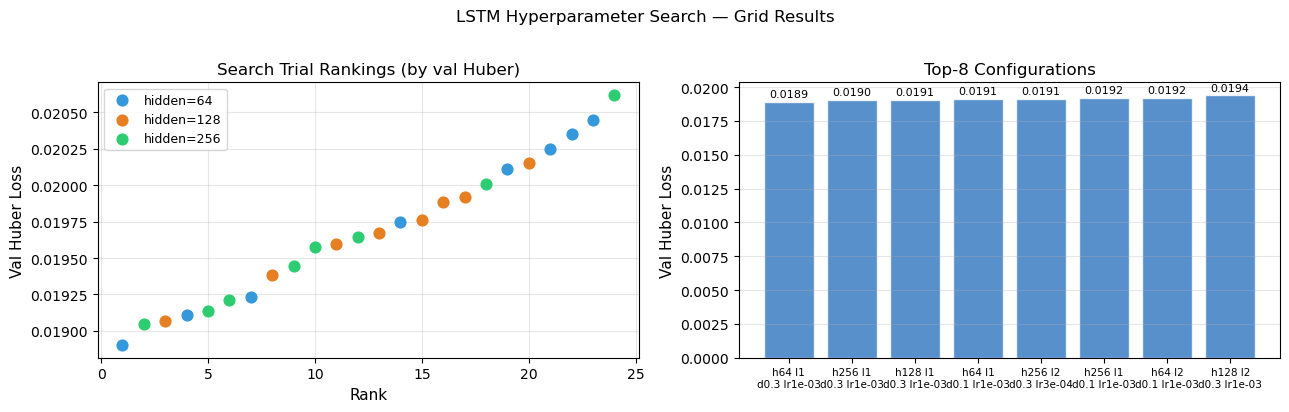

Saved: /Users/deansimmer/git/AAI-590-capstone-canadian-health/reports/figures/fig3_0_hp_search.png


In [53]:
# ── Visualise the search ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: scatter of all trials, colour by hidden_size
colors = {64: "#3498db", 128: "#e67e22", 256: "#2ecc71"}
for hs, grp in search_df.groupby("hidden_size"):
    axes[0].scatter(grp.index, grp["val_huber"], label=f"hidden={hs}",
                    color=colors[hs], s=60, zorder=3)
axes[0].set_xlabel("Rank", fontsize=11)
axes[0].set_ylabel("Val Huber Loss", fontsize=11)
axes[0].set_title("Search Trial Rankings (by val Huber)", fontsize=12)
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)

# Right: bar chart of top-8 configs
top8 = search_df.head(8)
labels = [f"h{int(r.hidden_size)} l{int(r.num_layers)}\nd{r.dropout:.1f} lr{r.learning_rate:.0e}"
          for _, r in top8.iterrows()]
bars = axes[1].bar(range(1, 9), top8["val_huber"], color="#2e74c0", alpha=0.8, edgecolor="white")
for bar, val in zip(bars, top8["val_huber"]):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0002,
                 f"{val:.4f}", ha="center", va="bottom", fontsize=8)
axes[1].set_xticks(range(1, 9))
axes[1].set_xticklabels(labels, fontsize=7.5)
axes[1].set_ylabel("Val Huber Loss", fontsize=11)
axes[1].set_title("Top-8 Configurations", fontsize=12)
axes[1].grid(axis="y", alpha=0.3)

fig.suptitle("LSTM Hyperparameter Search — Grid Results", fontsize=12, y=1.02)
plt.tight_layout()
hp_fig_path = os.path.join(FIGURES_DIR, "fig3_0_hp_search.png")
plt.savefig(hp_fig_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {hp_fig_path}")

---
## 8 · Full Training Run with Best Configuration

Re-train from scratch using the winning hyperparameters from the grid search, now with the full epoch budget and standard patience settings. This is the model whose weights and diagnostics are saved as the final artefacts.

In [54]:
# ── Extract best configuration ────────────────────────────────────────────────
best_cfg = search_df.iloc[0]
print("Best configuration from search:")
print(f"  hidden_size   : {int(best_cfg.hidden_size)}")
print(f"  num_layers    : {int(best_cfg.num_layers)}")
print(f"  dropout       : {best_cfg.dropout}")
print(f"  learning_rate : {best_cfg.learning_rate:.0e}")
print(f"  val_huber (search) : {best_cfg.val_huber:.5f}")

# Override the module-level hyperparameter constants with the winners
HIDDEN_SIZE   = int(best_cfg.hidden_size)
NUM_LAYERS    = int(best_cfg.num_layers)
DROPOUT       = float(best_cfg.dropout)
LEARNING_RATE = float(best_cfg.learning_rate)

# Record the winning config for downstream saving
RUN_CONFIG.update({
    "hidden_size":   HIDDEN_SIZE,
    "num_layers":    NUM_LAYERS,
    "dropout":       DROPOUT,
    "learning_rate": LEARNING_RATE,
    "search_val_huber": float(best_cfg.val_huber),
})
print("\nModule-level constants updated to best config.")

Best configuration from search:
  hidden_size   : 64
  num_layers    : 1
  dropout       : 0.3
  learning_rate : 1e-03
  val_huber (search) : 0.01890

Module-level constants updated to best config.


In [55]:
# ── Rebuild model, optimiser, scheduler with winning config ───────────────────
model = LSTMForecaster(
    n_features=N_FEATURES,
    hidden_size=HIDDEN_SIZE,
    num_layers=NUM_LAYERS,
    forecast_horizon=FORECAST_HORIZON,
    dropout=DROPOUT,
    fc_hidden=FC_HIDDEN,
).to(DEVICE)

optimizer = torch.optim.Adam(
    model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY,
)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=LR_FACTOR,
    patience=LR_PATIENCE, min_lr=LR_MIN,
)
criterion = nn.HuberLoss(delta=HUBER_DELTA)

total_params = sum(p.numel() for p in model.parameters())
print(model)
print(f"\nTotal parameters : {total_params:,}")

LSTMForecaster(
  (lstm): LSTM(6, 64, batch_first=True)
  (output_dropout): Dropout(p=0.3, inplace=False)
  (head): Sequential(
    (0): Linear(in_features=64, out_features=64, bias=True)
    (1): GELU(approximate='none')
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=64, out_features=8, bias=True)
  )
)

Total parameters : 23,112


In [56]:
# ── Full training run ─────────────────────────────────────────────────────────
best_model_path = os.path.join(MODEL_DIR, "lstm_baseline_best.pt")

hist_df, best_val_loss, best_epoch = full_training_run(
    model=model, train_loader=train_loader, val_loader=val_loader,
    criterion=criterion, optimizer=optimizer, scheduler=scheduler,
    max_epochs=MAX_EPOCHS, early_stop_pat=EARLY_STOP_PAT,
    checkpoint_path=best_model_path, verbose=True,
)

 Epoch   Train Huber   Val Huber          LR
--------------------------------------------------
     1      0.198382    0.027088    1.00e-03  ✓
     5      0.073340    0.021014    1.00e-03  ✓
    10      0.066410    0.019960    1.00e-03
    15      0.062941    0.019320    1.00e-03
    20      0.060181    0.021603    1.00e-03
    25      0.057482    0.022075    5.00e-04
    30      0.056302    0.022841    5.00e-04
    35      0.055116    0.024712    2.50e-04

Early stopping at epoch 36 (25 epochs without improvement).

Done in 2.2 min  |  Best epoch 11  |  Best val Huber 0.019066


---
## 9 · Save Training Artifacts

In [57]:
import json
import os
import pandas as pd
import torch

# ── 7.1  Save training history ─────────────────────────────────────────────────
hist_path = os.path.join(MODEL_DIR, "training_history.csv")
hist_df.to_csv(hist_path, index=False)
print(f"Training history saved : {hist_path}")

# ── 7.2  Save run config + best-epoch metadata ─────────────────────────────────
RUN_CONFIG["best_epoch"]    = best_epoch
RUN_CONFIG["best_val_mse"]  = best_val_loss
RUN_CONFIG["best_val_rmse"] = best_val_loss ** 0.5
RUN_CONFIG["total_epochs"]  = len(hist_df)
RUN_CONFIG["device"]        = str(DEVICE)

config_out = os.path.join(MODEL_DIR, "lstm_baseline_config.json")
with open(config_out, "w") as f:
    json.dump(RUN_CONFIG, f, indent=2)
print(f"Run config saved       : {config_out}")

print(f"Model weights saved    : {best_model_path}")

Training history saved : /Users/deansimmer/git/AAI-590-capstone-canadian-health/models/lstm_baseline/training_history.csv
Run config saved       : /Users/deansimmer/git/AAI-590-capstone-canadian-health/models/lstm_baseline/lstm_baseline_config.json
Model weights saved    : /Users/deansimmer/git/AAI-590-capstone-canadian-health/models/lstm_baseline/lstm_baseline_best.pt


---
## 10 · Evaluation on Validation Set

We reload the best checkpoint and compute per-horizon error metrics on the held-out validation set. The primary metric is **Root Mean Squared Error (RMSE)** in `cases_per_100k`, chosen for its interpretability in the same units as the target and its sensitivity to large errors — relevant in outbreak contexts. **Mean Absolute Error (MAE)** is reported alongside it as a magnitude-robust complement.

In [58]:
# ── Reload the best checkpoint ─────────────────────────────────────────────────
model.load_state_dict(torch.load(best_model_path, map_location=DEVICE))
model.eval()
print(f"Best model reloaded from epoch {best_epoch}.")

Best model reloaded from epoch 11.


In [59]:
def predict_all(loader: DataLoader) -> tuple[np.ndarray, np.ndarray]:
    """
    Run the model over an entire DataLoader and return concatenated
    predictions and ground-truth targets IN THE MODEL'S OUTPUT SPACE
    (i.e. log1p scale if USE_LOG1P=True).

    Use `to_original_scale` to convert back to cases_per_100k.
    """
    all_preds, all_targets = [], []
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(DEVICE, non_blocking=True)
            preds   = model(X_batch).cpu().numpy()
            all_preds.append(preds)
            all_targets.append(y_batch.numpy())
    return np.concatenate(all_preds), np.concatenate(all_targets)

def to_original_scale(arr: np.ndarray) -> np.ndarray:
    """Invert log1p transform if it was applied; otherwise identity."""
    return np.expm1(np.clip(arr, 0, None)) if USE_LOG1P else arr

# Generate validation predictions in transformed space
val_preds_t,   val_targets_t   = predict_all(val_loader)

# Denormalise to original cases_per_100k for interpretable metric reporting
val_preds_orig   = to_original_scale(val_preds_t)
val_targets_orig = to_original_scale(val_targets_t)

print(f"Val predictions shape (transformed) : {val_preds_t.shape}")
print(f"Val predictions shape (original)     : {val_preds_orig.shape}")
print(f"\nPrediction range (original scale):  "
      f"[{val_preds_orig.min():.3f},  {val_preds_orig.max():.3f}]  cases/100k")

Val predictions shape (transformed) : (3756, 8)
Val predictions shape (original)     : (3756, 8)

Prediction range (original scale):  [0.000,  12.693]  cases/100k


In [60]:
def compute_metrics(preds: np.ndarray,
                    targets: np.ndarray,
                    label: str = "") -> pd.DataFrame:
    """
    Compute MSE, RMSE, and MAE per forecast horizon step and overall.
    Expects arrays in the SAME scale (both original or both transformed).
    """
    errors = preds - targets
    rows = []
    for h in range(preds.shape[1]):
        mse  = np.mean(errors[:, h] ** 2)
        rmse = np.sqrt(mse)
        mae  = np.mean(np.abs(errors[:, h]))
        rows.append({"horizon_week": h + 1, "mse": mse, "rmse": rmse, "mae": mae})
    overall_mse  = np.mean(errors ** 2)
    rows.append({"horizon_week": "overall",
                 "mse": overall_mse, "rmse": np.sqrt(overall_mse),
                 "mae": np.mean(np.abs(errors))})
    df = pd.DataFrame(rows)
    if label:
        print(f"\n{'─'*55}")
        print(f"  Metrics — {label}")
        print(f"{'─'*55}")
        print(df.to_string(index=False, float_format="{:.6f}".format))
    return df

# Metrics in transformed (log1p) space — what the model was trained on
val_metrics_t = compute_metrics(val_preds_t, val_targets_t,
                                label="Validation (log1p scale — training objective)")

# Metrics in original scale — directly interpretable in cases/100k
val_metrics   = compute_metrics(val_preds_orig, val_targets_orig,
                                label="Validation (original scale — cases_per_100k)")

# Save metrics table
metrics_path = os.path.join(REPO_DIR, "reports", "tables", "val_metrics.csv")
os.makedirs(os.path.dirname(metrics_path), exist_ok=True)
val_metrics.to_csv(metrics_path, index=False)
print(f"\nMetrics saved: {metrics_path}")


───────────────────────────────────────────────────────
  Metrics — Validation (log1p scale — training objective)
───────────────────────────────────────────────────────
horizon_week      mse     rmse      mae
           1 0.020284 0.142422 0.070532
           2 0.026483 0.162735 0.076255
           3 0.032997 0.181652 0.082736
           4 0.040235 0.200588 0.092076
           5 0.044587 0.211157 0.109034
           6 0.048875 0.221077 0.111479
           7 0.053523 0.231349 0.114688
           8 0.057171 0.239104 0.122275
     overall 0.040519 0.201294 0.097384

───────────────────────────────────────────────────────
  Metrics — Validation (original scale — cases_per_100k)
───────────────────────────────────────────────────────
horizon_week      mse     rmse      mae
           1 0.497052 0.705019 0.139762
           2 0.601544 0.775593 0.152457
           3 0.608538 0.780089 0.159698
           4 0.624570 0.790297 0.174129
           5 0.534031 0.730774 0.191372
           6 0.4603

---
## 11 · Test Set Evaluation & Per-Group Metrics

Runs the best-epoch model on the held-out test set (2004–2021) and computes RMSE and MAE broken down by disease and province. These breakdowns are required by notebook `04` to make a like-for-like comparison with the ARIMA model, which was also evaluated at the disease and province level.

**Outputs saved:**
- `reports/tables/lstm_test_metrics.csv` — overall + per-horizon metrics on the test set
- `reports/tables/lstm_test_metrics_by_disease.csv` — RMSE / MAE per disease
- `reports/tables/lstm_test_metrics_by_province.csv` — RMSE / MAE per province

In [61]:
# ── 11.1  Load test metadata ─────────────────────────
test_meta_path = os.path.join(FEAT_DIR, "test_metadata_feat.csv")
test_meta = pd.read_csv(test_meta_path)

print(f"Test metadata loaded: {test_meta.shape}")
print(f"  Diseases  : {sorted(test_meta['disease'].unique())}")
print(f"  Provinces : {sorted(test_meta['province'].unique())}")
assert len(test_meta) == len(X_test), \
    f"Metadata rows ({len(test_meta)}) do not match test windows ({len(X_test)})"

Test metadata loaded: (3724, 2)
  Diseases  : ['influenza', 'measles', 'whooping-cough']
  Provinces : ['CA-AB', 'CA-ON']


In [62]:
# ── 11.2  Run predictions on the test set ─────────────────────────────────
model.eval()
test_preds_t,   test_targets_t   = predict_all(test_loader)
test_preds_orig   = to_original_scale(test_preds_t)    # (n_test, 8)  cases/100k
test_targets_orig = to_original_scale(test_targets_t)  # (n_test, 8)  cases/100k

print(f"\nTest predictions shape : {test_preds_orig.shape}")
print(f"Prediction range       : [{test_preds_orig.min():.3f},  {test_preds_orig.max():.3f}]  cases/100k")
print(f"Target range           : [{test_targets_orig.min():.3f},  {test_targets_orig.max():.3f}]  cases/100k")


Test predictions shape : (3724, 8)
Prediction range       : [0.000,  7.616]  cases/100k
Target range           : [0.000,  17.064]  cases/100k


In [63]:
# ── 11.3  Overall + per-horizon test metrics ──────────────────────────────
test_metrics = compute_metrics(
    test_preds_orig, test_targets_orig,
    label="Test set (original scale — cases_per_100k)"
)

test_metrics_path = os.path.join(REPO_DIR, "reports", "tables", "lstm_test_metrics.csv")
test_metrics.to_csv(test_metrics_path, index=False)
print(f"\nOverall test metrics saved: {test_metrics_path}")


───────────────────────────────────────────────────────
  Metrics — Test set (original scale — cases_per_100k)
───────────────────────────────────────────────────────
horizon_week      mse     rmse      mae
           1 0.372736 0.610521 0.156694
           2 0.557959 0.746966 0.183031
           3 0.713174 0.844496 0.203720
           4 0.864394 0.929728 0.227442
           5 0.999571 0.999786 0.261821
           6 1.100015 1.048816 0.276447
           7 1.185747 1.088920 0.290393
           8 1.248287 1.117267 0.307808
     overall 0.880235 0.938209 0.238419

Overall test metrics saved: /Users/deansimmer/git/AAI-590-capstone-canadian-health/reports/tables/lstm_test_metrics.csv


In [64]:
# ── 11.4  Per-disease metrics ──────────────────────────────────────────────
disease_rows = []
for disease, grp in test_meta.groupby("disease"):
    idx   = grp.index.to_numpy()
    preds = test_preds_orig[idx]      # (n_windows_for_disease, 8)
    truth = test_targets_orig[idx]
    errors = preds - truth
    rmse = float(np.sqrt(np.mean(errors ** 2)))
    mae  = float(np.mean(np.abs(errors)))
    disease_rows.append({
        "disease":    disease,
        "n_windows":  len(idx),
        "rmse":       round(rmse, 6),
        "mae":        round(mae,  6),
    })

lstm_by_disease = pd.DataFrame(disease_rows).sort_values("disease").reset_index(drop=True)
disease_path = os.path.join(REPO_DIR, "reports", "tables", "lstm_test_metrics_by_disease.csv")
lstm_by_disease.to_csv(disease_path, index=False)

print("\nLSTM test metrics by disease:")
print(lstm_by_disease.to_string(index=False))
print(f"\nSaved: {disease_path}")


LSTM test metrics by disease:
       disease  n_windows     rmse      mae
     influenza        931 1.868039 0.780204
       measles        931 0.034957 0.026562
whooping-cough       1862 0.122782 0.073456

Saved: /Users/deansimmer/git/AAI-590-capstone-canadian-health/reports/tables/lstm_test_metrics_by_disease.csv


In [65]:
# ── 11.5  Per-province metrics ─────────────────────────────────────────────
province_rows = []
for province, grp in test_meta.groupby("province"):
    idx   = grp.index.to_numpy()
    preds = test_preds_orig[idx]
    truth = test_targets_orig[idx]
    errors = preds - truth
    rmse = float(np.sqrt(np.mean(errors ** 2)))
    mae  = float(np.mean(np.abs(errors)))
    province_rows.append({
        "province":   province,
        "n_windows":  len(idx),
        "rmse":       round(rmse, 6),
        "mae":        round(mae,  6),
    })

lstm_by_province = pd.DataFrame(province_rows).sort_values("province").reset_index(drop=True)
province_path = os.path.join(REPO_DIR, "reports", "tables", "lstm_test_metrics_by_province.csv")
lstm_by_province.to_csv(province_path, index=False)

print("\nLSTM test metrics by province:")
print(lstm_by_province.to_string(index=False))
print(f"\nSaved: {province_path}")


LSTM test metrics by province:
province  n_windows     rmse      mae
   CA-AB        931 0.164065 0.103216
   CA-ON       2793 1.079201 0.283487

Saved: /Users/deansimmer/git/AAI-590-capstone-canadian-health/reports/tables/lstm_test_metrics_by_province.csv


In [66]:
# ── 11.6  Export raw weekly predictions for national aggregation (notebook 05) ──
# Reconstructs forecast dates by aligning each test window to the weekly
# test series in the main dataset. Only the 1-step-ahead prediction (horizon 0)
# is saved so we get one clean prediction per week per (disease, province).

main_df = pd.read_csv(
    os.path.join(REPO_DIR, "data", "processed", "final_modeling_dataset.csv"),
    parse_dates=["period_start_date"],
)

FOCUS_DISEASES   = ["influenza", "measles", "whooping-cough"]
FOCUS_PROVINCES  = ["CA-AB", "CA-ON"]

weekly_test_df = (
    main_df[
        (main_df["time_scale"]   == "wk") &
        (main_df["disease"].isin(FOCUS_DISEASES)) &
        (main_df["iso_3166_2"].isin(FOCUS_PROVINCES)) &
        (main_df["split"]        == "test")
    ]
    .rename(columns={"iso_3166_2": "province"})
    .sort_values(["disease", "province", "period_start_date"])
    [["disease", "province", "period_start_date", "population"]]
    .reset_index(drop=True)
)

records = []
for (disease, province), grp in test_meta.groupby(["disease", "province"]):
    date_series = (
        weekly_test_df[
            (weekly_test_df["disease"]  == disease) &
            (weekly_test_df["province"] == province)
        ]["period_start_date"]
        .sort_values()
        .reset_index(drop=True)
    )
    window_indices = grp.index.to_numpy()
    for w_pos, w_idx in enumerate(window_indices):
        if w_pos >= len(date_series):
            break
        records.append({
            "disease":              disease,
            "province":             province,
            "forecast_date":        date_series.iloc[w_pos].strftime("%Y-%m-%d"),
            "pred_cases_per_100k":  round(float(test_preds_orig[w_idx, 0]),  6),
            "actual_cases_per_100k": round(float(test_targets_orig[w_idx, 0]), 6),
        })

lstm_weekly_preds = pd.DataFrame(records)
lstm_preds_path = os.path.join(REPO_DIR, "reports", "tables", "lstm_weekly_predictions.csv")
lstm_weekly_preds.to_csv(lstm_preds_path, index=False)
print(f"Saved {len(lstm_weekly_preds):,} weekly LSTM predictions → {lstm_preds_path}")
print(lstm_weekly_preds.groupby(["disease", "province"]).size().to_string())
print(f"\nDate range: {lstm_weekly_preds['forecast_date'].min()} → {lstm_weekly_preds['forecast_date'].max()}")

Saved 3,473 weekly LSTM predictions → /Users/deansimmer/git/AAI-590-capstone-canadian-health/reports/tables/lstm_weekly_predictions.csv
disease         province
influenza       CA-ON       931
measles         CA-ON       777
whooping-cough  CA-AB       834
                CA-ON       931

Date range: 2004-01-04 → 2021-12-19


---
## 12 · Diagnostic Plots

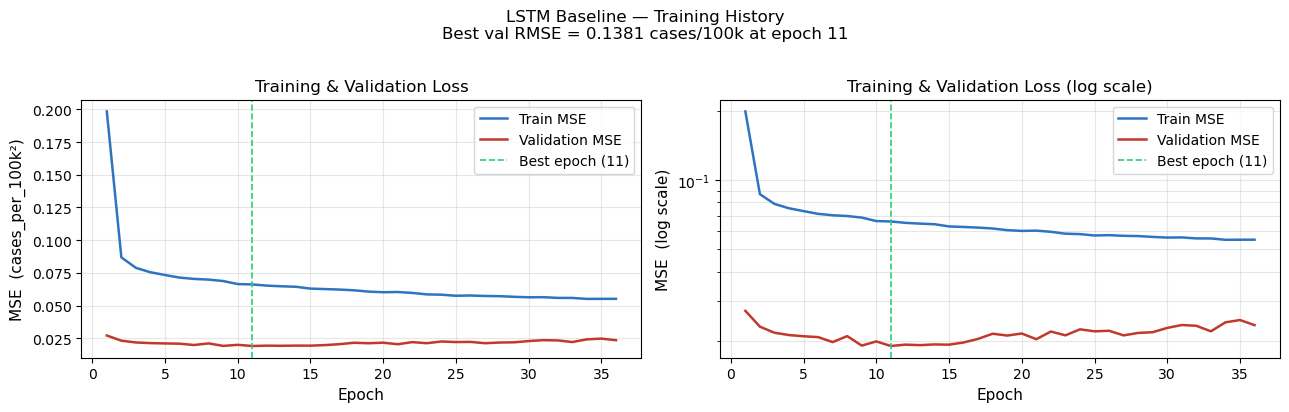

Saved: /Users/deansimmer/git/AAI-590-capstone-canadian-health/reports/figures/lstm_training_curves.png


In [67]:
# ── Figure 1: Training and validation loss curves ─────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

epochs_range = hist_df["epoch"].values

# Left panel — MSE curves on linear scale
ax = axes[0]
ax.plot(epochs_range, hist_df["train_loss"], label="Train MSE",      color="#2e74c0", lw=1.8)
ax.plot(epochs_range, hist_df["val_loss"],   label="Validation MSE", color="#c0392b", lw=1.8)
ax.axvline(best_epoch, color="#2ecc71", lw=1.2, linestyle="--",
           label=f"Best epoch ({best_epoch})")
ax.set_xlabel("Epoch", fontsize=11)
ax.set_ylabel("MSE  (cases_per_100k²)", fontsize=11)
ax.set_title("Training & Validation Loss", fontsize=12)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

# Right panel — log-scale view (highlights early convergence behaviour)
ax = axes[1]
ax.semilogy(epochs_range, hist_df["train_loss"], label="Train MSE",      color="#2e74c0", lw=1.8)
ax.semilogy(epochs_range, hist_df["val_loss"],   label="Validation MSE", color="#c0392b", lw=1.8)
ax.axvline(best_epoch, color="#2ecc71", lw=1.2, linestyle="--",
           label=f"Best epoch ({best_epoch})")
ax.set_xlabel("Epoch", fontsize=11)
ax.set_ylabel("MSE  (log scale)", fontsize=11)
ax.set_title("Training & Validation Loss (log scale)", fontsize=12)
ax.legend(fontsize=10)
ax.grid(alpha=0.3, which="both")

fig.suptitle(
    "LSTM Baseline — Training History\n"
    f"Best val RMSE = {best_val_loss**0.5:.4f} cases/100k at epoch {best_epoch}",
    fontsize=12, y=1.02
)
plt.tight_layout()
curves_path = os.path.join(FIGURES_DIR, "lstm_training_curves.png")
plt.savefig(curves_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {curves_path}")

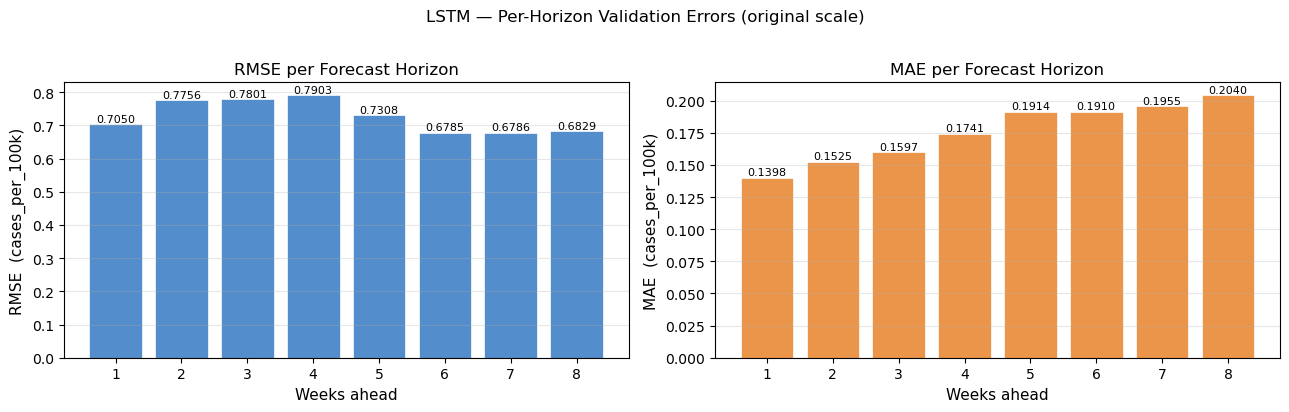

Saved: /Users/deansimmer/git/AAI-590-capstone-canadian-health/reports/figures/fig3_1b_lstm_per_horizon_errors.png


In [68]:
# ── Figure 2: Per-horizon RMSE and MAE (original cases_per_100k scale) ────────
ph_metrics = val_metrics[val_metrics["horizon_week"] != "overall"].copy()
ph_metrics["horizon_week"] = ph_metrics["horizon_week"].astype(int)

fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=False)
for ax, metric, color, title in [
    (axes[0], "rmse", "#2e74c0", "RMSE per Forecast Horizon"),
    (axes[1], "mae",  "#e67e22", "MAE per Forecast Horizon"),
]:
    bars = ax.bar(ph_metrics["horizon_week"], ph_metrics[metric],
                  color=color, alpha=0.82, edgecolor="white", linewidth=0.6)
    for bar, val in zip(bars, ph_metrics[metric]):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.0005,
                f"{val:.4f}", ha="center", va="bottom", fontsize=8)
    ax.set_xlabel("Weeks ahead", fontsize=11)
    ax.set_ylabel(f"{metric.upper()}  (cases_per_100k)", fontsize=11)
    ax.set_title(title, fontsize=12)
    ax.set_xticks(ph_metrics["horizon_week"])
    ax.grid(axis="y", alpha=0.3)

fig.suptitle("LSTM — Per-Horizon Validation Errors (original scale)", fontsize=12, y=1.02)
plt.tight_layout()
horizon_path = os.path.join(FIGURES_DIR, "fig3_1b_lstm_per_horizon_errors.png")
plt.savefig(horizon_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {horizon_path}")

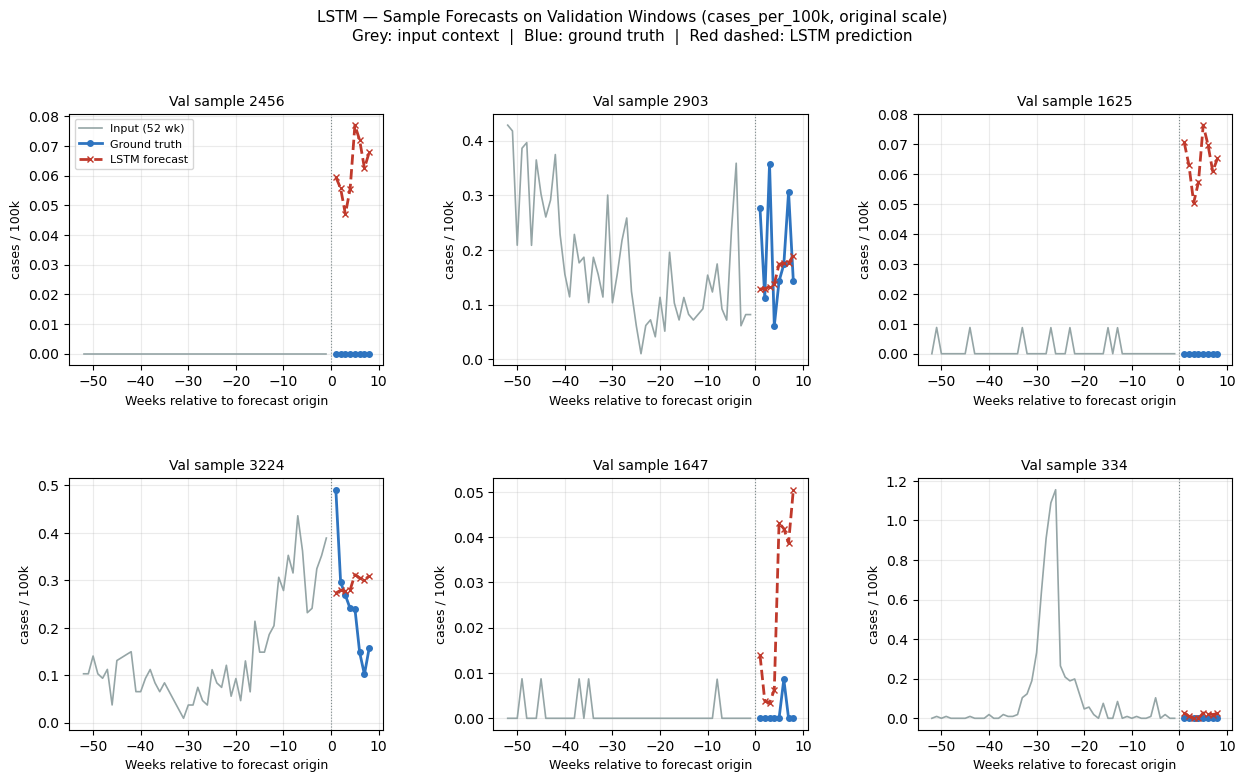

Saved: /Users/deansimmer/git/AAI-590-capstone-canadian-health/reports/figures/fig3_2_lstm_forecast_samples.png


In [69]:
# ── Figure 3: Forecast overlays on random validation windows (original scale) ──
N_SAMPLES  = 6
rng        = np.random.default_rng(SEED)
sample_idx = rng.choice(len(X_val), size=N_SAMPLES, replace=False)

fig = plt.figure(figsize=(15, 8))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

lookback_x = np.arange(-LOOKBACK_WEEKS, 0)
horizon_x  = np.arange(1, FORECAST_HORIZON + 1)

for i, idx in enumerate(sample_idx):
    ax      = fig.add_subplot(gs[i // 3, i % 3])
    context = X_val[idx, :, TARGET_FEATURE_IDX]          # cases_per_100k (raw feature)
    truth   = val_targets_orig[idx]                       # original scale ground truth
    pred    = val_preds_orig[idx]                         # original scale prediction

    ax.plot(lookback_x, context,  color="#95a5a6", lw=1.2, label="Input (52 wk)")
    ax.plot(horizon_x, truth, color="#2e74c0", lw=2, marker="o", ms=4, label="Ground truth")
    ax.plot(horizon_x, pred,  color="#c0392b", lw=2, marker="x", ms=5,
            linestyle="--", label="LSTM forecast")
    ax.axvline(0, color="#7f8c8d", lw=0.8, linestyle=":")
    ax.set_xlabel("Weeks relative to forecast origin", fontsize=9)
    ax.set_ylabel("cases / 100k", fontsize=9)
    ax.set_title(f"Val sample {idx}", fontsize=10)
    ax.grid(alpha=0.25)
    if i == 0:
        ax.legend(fontsize=8, loc="upper left")

fig.suptitle(
    "LSTM — Sample Forecasts on Validation Windows (cases_per_100k, original scale)\n"
    "Grey: input context  |  Blue: ground truth  |  Red dashed: LSTM prediction",
    fontsize=11, y=1.01
)
samples_path = os.path.join(FIGURES_DIR, "fig3_2_lstm_forecast_samples.png")
plt.savefig(samples_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {samples_path}")

## 13. Final Test Evaluation (for Model Comparison)

In [70]:
# Create predictions on the test set
test_preds_t, test_targets_t = predict_all(test_loader)

# Convert this back to og scale
test_preds = to_original_scale(test_preds_t)
test_targets = to_original_scale(test_targets_t)

print("Test pred shape:", test_preds.shape)

# Compute the test metrics
lstm_test_df = compute_metrics(
    test_preds,
    test_targets,
    label="test"
)

print("\nLSTM test metrics:")
display(lstm_test_df)

REPO_TABLES = os.path.join(REPO_DIR, "reports", "tables")
os.makedirs(REPO_TABLES, exist_ok=True)

repo_lstm_path = os.path.join(REPO_TABLES, "lstm_test_metrics.csv")
lstm_test_df.to_csv(repo_lstm_path, index=False)

print("\nSaved LSTM test metrics:")
print(repo_lstm_path)

Test pred shape: (3724, 8)

───────────────────────────────────────────────────────
  Metrics — test
───────────────────────────────────────────────────────
horizon_week      mse     rmse      mae
           1 0.372736 0.610521 0.156694
           2 0.557959 0.746966 0.183031
           3 0.713174 0.844496 0.203720
           4 0.864394 0.929728 0.227442
           5 0.999571 0.999786 0.261821
           6 1.100015 1.048816 0.276447
           7 1.185747 1.088920 0.290393
           8 1.248287 1.117267 0.307808
     overall 0.880235 0.938209 0.238419

LSTM test metrics:


,horizon_week,mse,rmse,mae
0,1,0.372736,0.610521,0.156694
1,2,0.557959,0.746966,0.183031
2,3,0.713174,0.844496,0.203720
3,4,0.864394,0.929728,0.227442
4,5,0.999571,0.999786,0.261821
5,6,1.100015,1.048816,0.276447
6,7,1.185747,1.088920,0.290393
7,8,1.248287,1.117267,0.307808
8,overall,0.880235,0.938209,0.238419



Saved LSTM test metrics:
/Users/deansimmer/git/AAI-590-capstone-canadian-health/reports/tables/lstm_test_metrics.csv
